In [62]:
import os
import torch
import torch.nn as nn

import numpy as np
import pandas as pd

from obspy import read

import matplotlib.pyplot as plt

from scipy.ndimage import uniform_filter1d

In [63]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [64]:
class SeismicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SeismicCNN().to(device)

In [65]:
LABEL_MAP = {
    0: "Noise",
    1: "Avalanche",
    2: "Earthquake"
}

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = SeismicCNN().to(device)

model.load_state_dict(
    torch.load(
        r"D:\Seismic_Monitoring_AI\models\best_seismic_model_v3.pth",
        map_location=device
    )
)

model.eval()

print("Model Loaded")

Model Loaded


C:\Users\RITESH KUMAR\AppData\Local\Temp\ipykernel_18408\849548793.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


In [66]:
file_path = r"D:\Seismic_Monitoring_AI\data\raw\dischma_data\dischma_data\season_2020_21\CS\DSMA.CS.EHZ_20210113_0459-20210113_0505.mseed"

tr = read(file_path)[0]

signal = tr.data.astype(np.float32)

fs = tr.stats.sampling_rate

print(len(signal))
print(fs)

72001
200.0


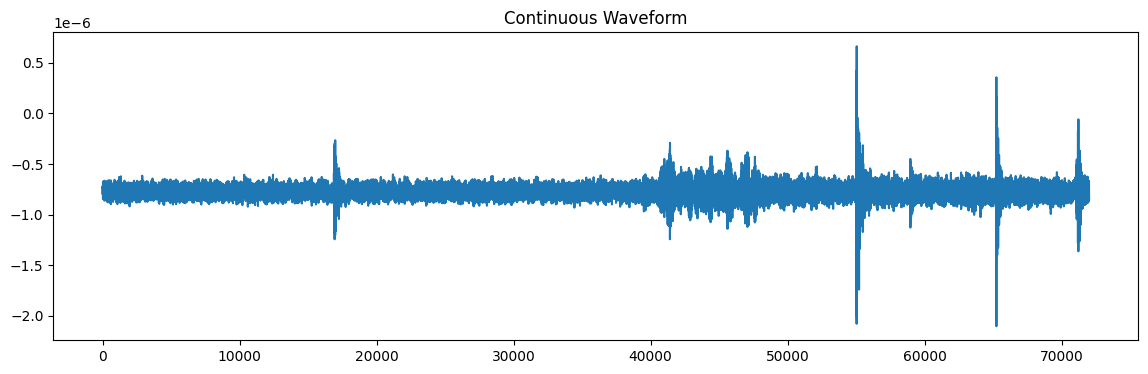

In [67]:
plt.figure(figsize=(14,4))

plt.plot(signal)

plt.title("Continuous Waveform")

plt.show()

In [68]:
def detect_events(
    signal,
    smooth_window=1000,
    threshold_factor=2.5,
    min_length=1000
):

    energy = signal**2

    energy = uniform_filter1d(
        energy,
        size=smooth_window
    )

    threshold = (
        energy.mean()
        + threshold_factor * energy.std()
    )

    mask = energy > threshold

    events = []

    start = None

    for i, val in enumerate(mask):

        if val and start is None:
            start = i

        elif not val and start is not None:

            if i - start > min_length:

                events.append(
                    (start, i)
                )

            start = None

    return events, energy, threshold

In [69]:
events, energy, threshold = detect_events(
    signal
)

print(
    "Detected Events:",
    len(events)
)

events

Detected Events: 1


[(54555, 55631)]

In [76]:
for start, end in events:

    segment = signal[start:end]

    print("Segment length:", len(segment))

Segment length: 1076


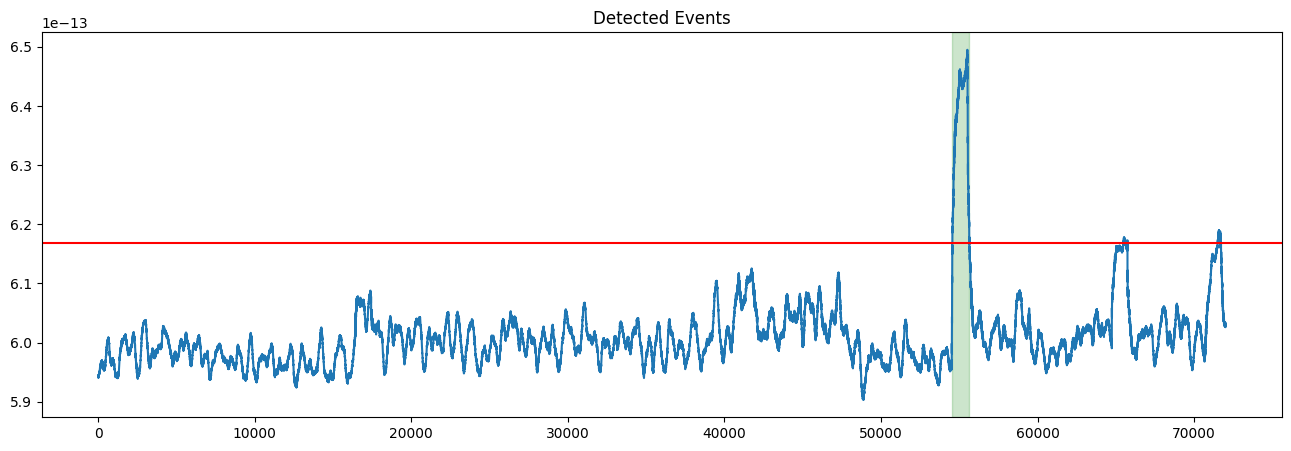

In [70]:
plt.figure(figsize=(16,5))

plt.plot(energy)

plt.axhline(
    threshold,
    color="red"
)

for start, end in events:

    plt.axvspan(
        start,
        end,
        color="green",
        alpha=0.2
    )

plt.title(
    "Detected Events"
)

plt.show()

In [71]:
WINDOW_SIZE = 2000

def classify_event(signal, start, end):

    segment = signal[start:end]

    if len(segment) == 0:
        return None

    # Use strongest energy point instead of midpoint
    peak = np.argmax(segment**2)

    center = start + peak

    left = center - WINDOW_SIZE // 2
    right = center + WINDOW_SIZE // 2

    if left < 0:
        return None

    if right > len(signal):
        return None

    window = signal[left:right]

    # Same normalization used during training
    window = (
        window - window.mean()
    ) / (
        window.std() + 1e-8
    )

    # Debug plot
    plt.figure(figsize=(12,3))
    plt.plot(window)
    plt.title(
        f"Window Sent To CNN | Center={center}"
    )
    plt.show()

    tensor = torch.tensor(
        window,
        dtype=torch.float32
    )

    tensor = tensor.unsqueeze(0)
    tensor = tensor.unsqueeze(0)

    tensor = tensor.to(device)

    with torch.no_grad():

        logits = model(tensor)

        probs = torch.softmax(
            logits,
            dim=1
        )

        pred = torch.argmax(
            probs,
            dim=1
        )

    print(
        f"Start={start}, End={end}, Center={center}"
    )

    print(
        "Probabilities:",
        probs.cpu().numpy()[0]
    )

    return (
        LABEL_MAP[pred.item()],
        probs.cpu().numpy()[0]
    )

In [77]:
results = []

for start, end in events:

    center = (start + end) // 2

    left = center - WINDOW_SIZE // 2
    right = center + WINDOW_SIZE // 2

    if left < 0:
        continue

    if right > len(signal):
        continue

    window = signal[left:right]

    window = (
        window - window.mean()
    ) / (
        window.std() + 1e-8
    )

    tensor = torch.tensor(
        window,
        dtype=torch.float32
    )

    tensor = tensor.unsqueeze(0)
    tensor = tensor.unsqueeze(0)

    tensor = tensor.to(device)

    with torch.no_grad():

        logits = model(tensor)

        probs = torch.softmax(
            logits,
            dim=1
        )

        pred = torch.argmax(
            probs,
            dim=1
        )

    results.append({

        "Start": start,
        "End": end,
        "Prediction": LABEL_MAP[pred.item()],
        "Noise": probs[0][0].item(),
        "Avalanche": probs[0][1].item(),
        "Earthquake": probs[0][2].item()

    })

results_df = pd.DataFrame(results)

results_df

,Start,End,Prediction,Noise,Avalanche,Earthquake
0,54555,55631,Noise,0.665672,0.062522,0.271806


In [78]:
results_df.columns
results_df.head()
results_df.shape

(1, 6)

In [79]:
results_df.sort_values(
    "Earthquake",
    ascending=False
).head(20)

,Start,End,Prediction,Noise,Avalanche,Earthquake
0,54555,55631,Noise,0.665672,0.062522,0.271806
